In [2]:
import pandas as pd
import numpy as np

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)
benchmark = benchmark.sort_values(["index_name", "date"]).reset_index(drop=True)

print("NAV Shape:", nav.shape)
print("Benchmark Shape:", benchmark.shape)

print("\nDate Range")
print(nav["date"].min(), "to", nav["date"].max())

print("\nUnique Schemes:", nav["amfi_code"].nunique())

print("\nMissing NAV values")
print(nav.isna().sum())

NAV Shape: (46000, 3)
Benchmark Shape: (8050, 3)

Date Range
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Unique Schemes: 40

Missing NAV values
amfi_code    0
date         0
nav          0
dtype: int64


In [4]:
# Daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove first observation for each scheme
daily_returns = nav.dropna(subset=["daily_return"]).copy()

print(daily_returns.head())

   amfi_code        date       nav  daily_return
1     100016  2022-01-04  515.0971     -0.010306
2     100016  2022-01-05  521.7239      0.012865
3     100016  2022-01-06  515.7880     -0.011377
4     100016  2022-01-07  515.1639     -0.001210
5     100016  2022-01-10  510.7136     -0.008639


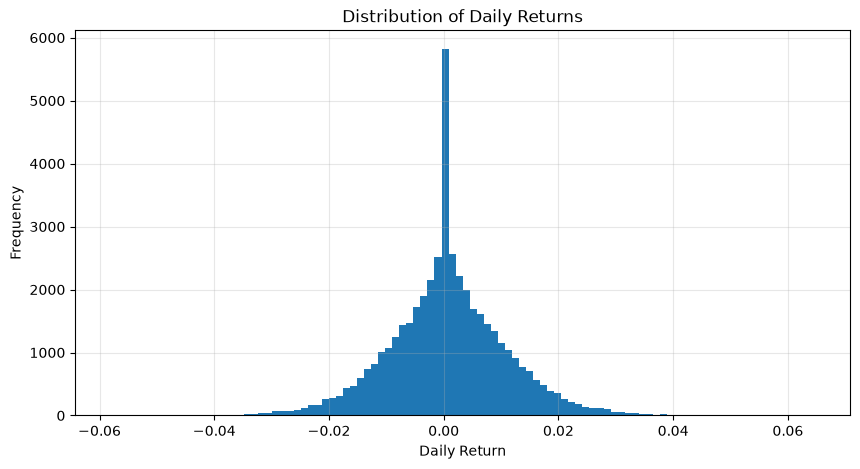

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    daily_returns["daily_return"],
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [8]:
daily_returns["daily_return"].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
1%          -0.025982
5%          -0.016254
25%         -0.005042
50%          0.000340
75%          0.006324
95%          0.017842
99%          0.027617
max          0.064713
Name: daily_return, dtype: float64

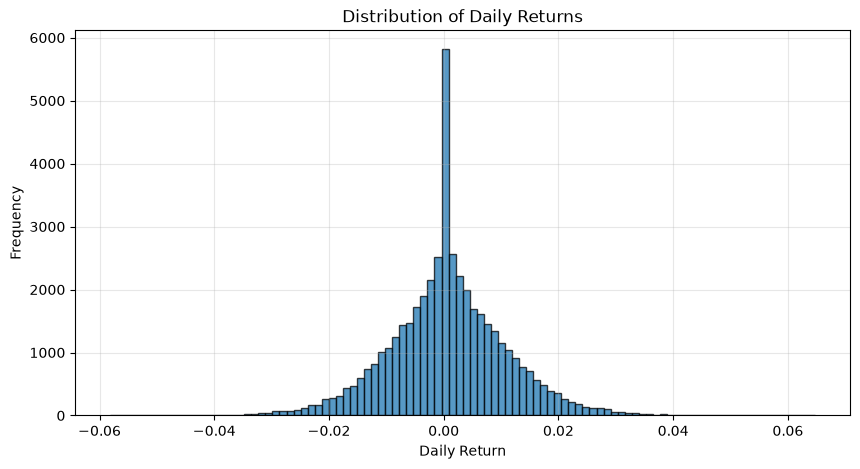

✅ Chart saved to: ../outputs/charts/daily_return_distribution.png


In [10]:
import os
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
os.makedirs("../outputs/charts", exist_ok=True)

plt.figure(figsize=(10, 5))

plt.hist(
    daily_returns["daily_return"],
    bins=100,
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

# Save figure
plt.savefig(
    "../outputs/charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to: ../outputs/charts/daily_return_distribution.png")

In [20]:
from pandas.tseries.offsets import DateOffset

def calculate_cagr(group, years):
    """
    Calculate CAGR for the specified number of years using
    the nearest available NAV dates.
    """
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_target = end_date - DateOffset(years=years)

    # Find nearest available trading day
    start_idx = (group["date"] - start_target).abs().idxmin()

    start_nav = group.loc[start_idx, "nav"]
    end_nav = group.iloc[-1]["nav"]

    actual_start_date = group.loc[start_idx, "date"]
    actual_end_date = group.iloc[-1]["date"]

    actual_years = (actual_end_date - actual_start_date).days / 365.25

    if start_nav <= 0:
        return np.nan

    cagr = (end_nav / start_nav) ** (1 / actual_years) - 1

    return cagr * 100

In [22]:
cagr_table = []

for code, group in nav.groupby("amfi_code"):

    cagr_table.append({
        "amfi_code": code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_table)

TypeError: unsupported operand type(s) for -: 'str' and 'DateOffset'

In [23]:
type(nav["date"].iloc[0])

str

In [27]:
for code, group in nav.groupby("amfi_code"):
    print(type(group["date"].iloc[0]))
    break

<class 'str'>


In [31]:
import pandas as pd

print("Before conversion:", type(nav["date"].iloc[0]))

nav["date"] = pd.to_datetime(nav["date"], errors="raise")

print("After conversion:", type(nav["date"].iloc[0]))
print(nav.dtypes)

Before conversion: <class 'str'>
After conversion: <class 'pandas.Timestamp'>
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [35]:
from pandas.tseries.offsets import DateOffset
import numpy as np
import pandas as pd

def calculate_cagr(group, years):

    group = group.copy()
    group["date"] = pd.to_datetime(group["date"])
    group = group.sort_values("date")

    end_date = group["date"].iloc[-1]
    target_date = end_date - DateOffset(years=years)

    start_idx = (group["date"] - target_date).abs().idxmin()

    start_nav = group.loc[start_idx, "nav"]
    end_nav = group.iloc[-1]["nav"]

    start_date = group.loc[start_idx, "date"]

    actual_years = (end_date - start_date).days / 365.25

    if actual_years <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / actual_years) - 1) * 100

In [39]:
code, group = next(iter(nav.groupby("amfi_code")))

print(code)
print(calculate_cagr(group, 1))

100016
-2.2257773892688015


In [43]:
cagr_table = []

for code, group in nav.groupby("amfi_code"):
    cagr_table.append({
        "amfi_code": code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5),
    })

cagr_df = pd.DataFrame(cagr_table)

In [47]:
# Merge with fund master
cagr_df = cagr_df.merge(
    fund[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

# Reorder columns
cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

cagr_df.head()

,amfi_code,scheme_name,fund_house,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,-2.225777,1.292353,2.637074
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,3.707553,3.915479,4.458210
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.277195,32.433971,30.123153
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.963794,28.960211,23.538361
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-24.000309,-4.151454,7.938765


In [51]:
cagr_df.isna().sum()

amfi_code      0
scheme_name    0
fund_house     0
CAGR_1Y        0
CAGR_3Y        0
CAGR_5Y        0
dtype: int64

In [55]:
top_10_cagr = (
    cagr_df.sort_values("CAGR_3Y", ascending=False)
           .reset_index(drop=True)
)

top_10_cagr.head(10)

,amfi_code,scheme_name,fund_house,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,22.277897,35.102528,28.214417
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,20.375957,33.991970,30.974108
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,13.073788,32.478927,23.295119
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.277195,32.433971,30.123153
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.627681,31.769243,32.827406
5,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.489297,30.448613,25.804686
6,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,26.677584,29.575111,30.907455
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,39.783803,29.171358,31.949523
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.963794,28.960211,23.538361
9,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,65.195466,26.993503,32.287440


In [59]:
import os

os.makedirs("../outputs/reports", exist_ok=True)

cagr_df.to_csv(
    "../outputs/reports/cagr_comparison.csv",
    index=False
)

print("✅ CAGR comparison table saved successfully.")

✅ CAGR comparison table saved successfully.


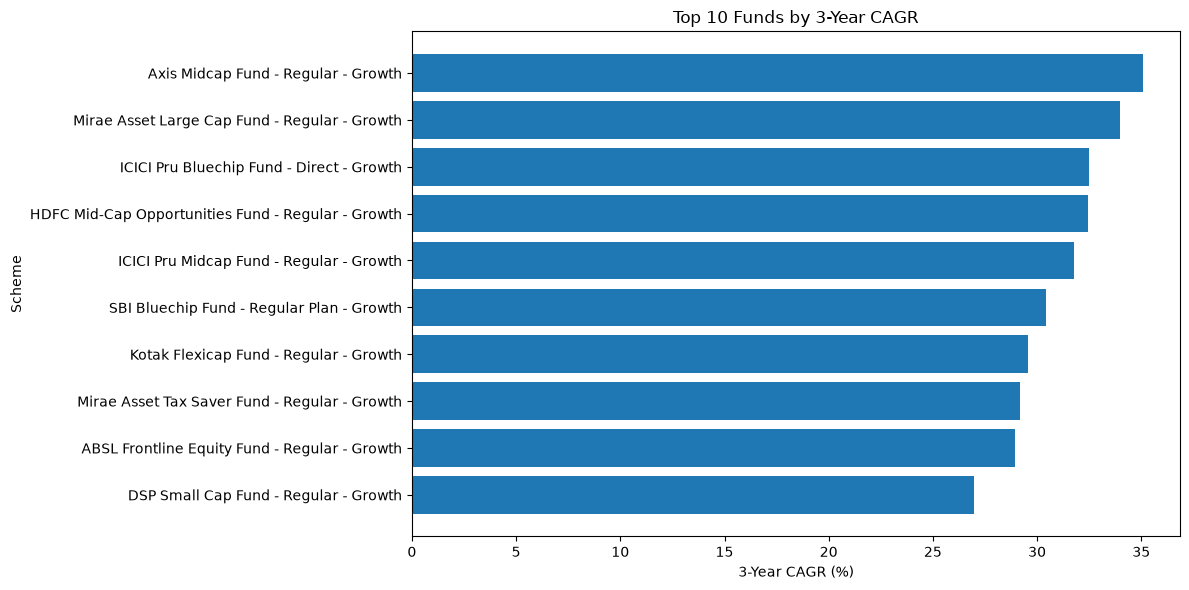

✅ Chart saved to outputs/charts/top10_cagr_3yr.png


In [63]:
import matplotlib.pyplot as plt

top10 = (
    cagr_df.nlargest(10, "CAGR_3Y")
           .sort_values("CAGR_3Y")
)

plt.figure(figsize=(12, 6))

plt.barh(
    top10["scheme_name"],
    top10["CAGR_3Y"]
)

plt.xlabel("3-Year CAGR (%)")
plt.ylabel("Scheme")
plt.title("Top 10 Funds by 3-Year CAGR")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top10_cagr_3yr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved to outputs/charts/top10_cagr_3yr.png")

In [67]:
comparison = (
    cagr_df.merge(
        scheme[
            ["amfi_code", "return_1yr_pct", "return_3yr_pct", "return_5yr_pct"]
        ],
        on="amfi_code",
        how="left"
    )
)

comparison[
    [
        "scheme_name",
        "CAGR_1Y",
        "return_1yr_pct",
        "CAGR_3Y",
        "return_3yr_pct"
    ]
].head(10)

,scheme_name,CAGR_1Y,return_1yr_pct,CAGR_3Y,return_3yr_pct
0,HDFC Top 100 Fund - Regular Plan - Growth,-2.225777,10.94,1.292353,14.84
1,HDFC Short Term Debt Fund - Regular - Growth,3.707553,6.83,3.915479,7.37
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.277195,15.43,32.433971,16.58
3,ABSL Frontline Equity Fund - Regular - Growth,47.963794,14.82,28.960211,13.78
4,ABSL Small Cap Fund - Regular - Growth,-24.000309,24.93,-4.151454,22.38
5,ABSL Liquid Fund - Regular - Growth,7.241777,6.18,6.314299,5.14
6,UTI Nifty 50 Index Fund - Regular - Growth,20.222859,13.76,19.662361,12.10
7,UTI Mid Cap Fund - Regular - Growth,-16.807960,16.30,-0.767232,15.61
8,UTI Flexi Cap Fund - Regular - Growth,13.593044,17.43,25.549670,15.34
9,Nippon India Large Cap Fund - Regular - Growth,34.007896,15.84,22.646647,14.00


In [71]:
# Annual risk-free rate
RF = 0.065

# Daily risk-free rate
rf_daily = RF / 252

sharpe_df = (
    daily_returns
    .groupby("amfi_code")
    .agg(
        mean_daily_return=("daily_return", "mean"),
        std_daily_return=("daily_return", "std")
    )
    .reset_index()
)

# Annualized Return
sharpe_df["annual_return"] = sharpe_df["mean_daily_return"] * 252

# Annualized Volatility
sharpe_df["annual_volatility"] = sharpe_df["std_daily_return"] * np.sqrt(252)

sharpe_df.head()

,amfi_code,mean_daily_return,std_daily_return,annual_return,annual_volatility
0,100016,0.000142,0.009164,0.035683,0.145481
1,100025,0.000170,0.002460,0.042854,0.039052
2,100033,0.001080,0.011929,0.272111,0.189367
3,101206,0.000852,0.009177,0.214647,0.145682
4,101207,0.000424,0.016251,0.106962,0.257973


In [75]:
sharpe_df["Sharpe_Ratio"] = (
    (sharpe_df["annual_return"] - RF)
    / sharpe_df["annual_volatility"]
)

In [79]:
sharpe_df = sharpe_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df = sharpe_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "annual_return",
        "annual_volatility",
        "Sharpe_Ratio"
    ]
]

In [83]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df.head(10)

,amfi_code,scheme_name,fund_house,annual_return,annual_volatility,Sharpe_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,0.270566,0.141937,1.448291
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,0.272602,0.158870,1.306744
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,0.283262,0.176740,1.234930
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.231033,0.137414,1.208267
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.292653,0.192909,1.180101
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.265908,0.177462,1.132122
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.272111,0.189367,1.093699
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,0.218037,0.141484,1.081659
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,0.214647,0.145682,1.027213
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.212448,0.143638,1.026524


In [87]:
sharpe_df.to_csv(
    "../outputs/reports/sharpe_ratio.csv",
    index=False
)

print("✅ Sharpe Ratio table saved.")

✅ Sharpe Ratio table saved.


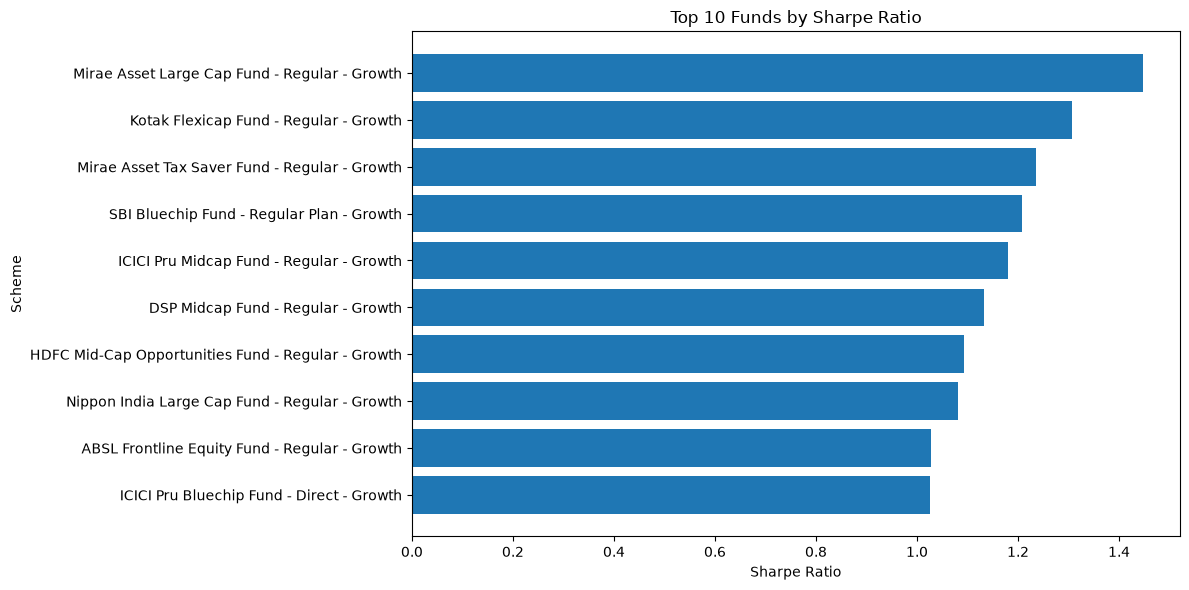

✅ Chart saved.


In [91]:
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/charts", exist_ok=True)

top10 = (
    sharpe_df
    .nlargest(10, "Sharpe_Ratio")
    .sort_values("Sharpe_Ratio")
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Sharpe_Ratio"]
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")
plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top10_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved.")

In [95]:
RF = 0.065

def calculate_sortino(group):
    """
    Calculate annualized Sortino Ratio for a single fund.
    """
    returns = group["daily_return"]

    # Downside returns only
    downside = returns[returns < 0]

    mean_return = returns.mean() * 252

    # Annualized downside deviation
    downside_std = downside.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        return np.nan

    return (mean_return - RF) / downside_std

In [99]:
sortino_table = []

for code, group in daily_returns.groupby("amfi_code"):

    sortino_table.append({
        "amfi_code": code,
        "Sortino_Ratio": calculate_sortino(group)
    })

sortino_df = pd.DataFrame(sortino_table)

In [103]:
sortino_df = sortino_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name,fund_house
0,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.875101,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
7,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
8,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
9,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


In [107]:
sortino_df.to_csv(
    "../outputs/reports/sortino_ratio.csv",
    index=False
)

print("✅ Sortino Ratio saved.")

✅ Sortino Ratio saved.


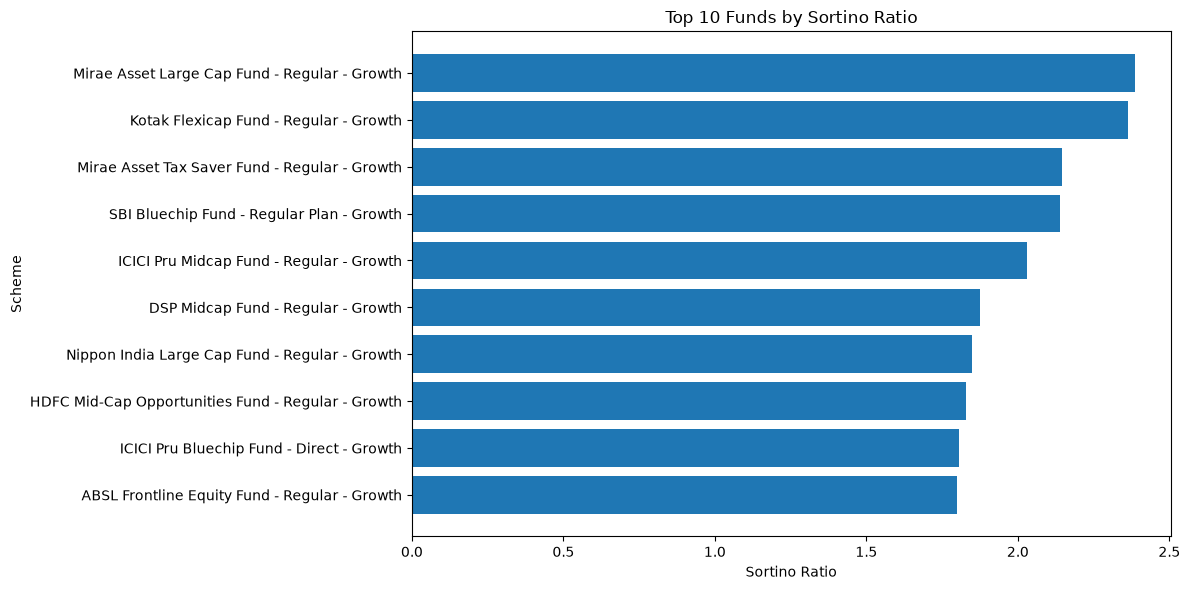

✅ Chart saved.


In [111]:
import matplotlib.pyplot as plt

top10 = (
    sortino_df
    .nlargest(10, "Sortino_Ratio")
    .sort_values("Sortino_Ratio")
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Sortino_Ratio"]
)

plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme")
plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top10_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved.")

In [115]:
# Keep only NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Daily returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Remove first NA
nifty100 = nifty100.dropna()

print(nifty100.head())

            date index_name  close_value  benchmark_return
1151  2022-01-04   NIFTY100     17537.52         -0.013540
1152  2022-01-05   NIFTY100     17607.73          0.004003
1153  2022-01-06   NIFTY100     17556.05         -0.002935
1154  2022-01-07   NIFTY100     17664.02          0.006150
1155  2022-01-10   NIFTY100     17516.51         -0.008351


In [119]:
merged_returns = daily_returns.merge(
    nifty100[
        [
            "date",
            "benchmark_return"
        ]
    ],
    on="date",
    how="inner"
)

print(merged_returns.head())

   amfi_code        date       nav  daily_return  benchmark_return
0     100016  2022-01-04  515.0971     -0.010306         -0.013540
1     100016  2022-01-05  521.7239      0.012865          0.004003
2     100016  2022-01-06  515.7880     -0.011377         -0.002935
3     100016  2022-01-07  515.1639     -0.001210          0.006150
4     100016  2022-01-10  510.7136     -0.008639         -0.008351


In [123]:
from scipy.stats import linregress

In [127]:
alpha_beta = []

for code, group in merged_returns.groupby("amfi_code"):

    regression = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha_beta.append({

        "amfi_code": code,

        "Alpha": regression.intercept * 252,

        "Beta": regression.slope,

        "R_squared": regression.rvalue ** 2,

        "P_value": regression.pvalue

    })

alpha_beta_df = pd.DataFrame(alpha_beta)

In [131]:
alpha_beta_df = alpha_beta_df.merge(

    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],

    on="amfi_code",

    how="left"

)

alpha_beta_df = alpha_beta_df[
    [

        "amfi_code",

        "scheme_name",

        "fund_house",

        "Alpha",

        "Beta",

        "R_squared",

        "P_value"

    ]
]

In [135]:
alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).reset_index(drop=True)

alpha_beta_df.head(10)

,amfi_code,scheme_name,fund_house,Alpha,Beta,R_squared,P_value
0,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.303370,-0.023196,1.414258e-04,0.687179
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,0.300579,0.011455,3.532991e-05,0.840494
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.292636,0.000549,1.345534e-07,0.990090
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,0.282704,0.018134,1.748889e-04,0.654295
4,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,0.273305,-0.022830,3.430543e-04,0.530528
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.271954,0.005104,1.206652e-05,0.906369
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,0.269838,0.023684,4.625437e-04,0.466427
7,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.265986,-0.002523,3.357978e-06,0.950525
8,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,0.260767,-0.066265,1.936879e-03,0.135988
9,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.232010,-0.031751,8.869789e-04,0.313143


In [139]:
alpha_beta_df.to_csv(
    "../outputs/reports/alpha_beta.csv",
    index=False
)

print("✅ alpha_beta.csv exported successfully.")

✅ alpha_beta.csv exported successfully.


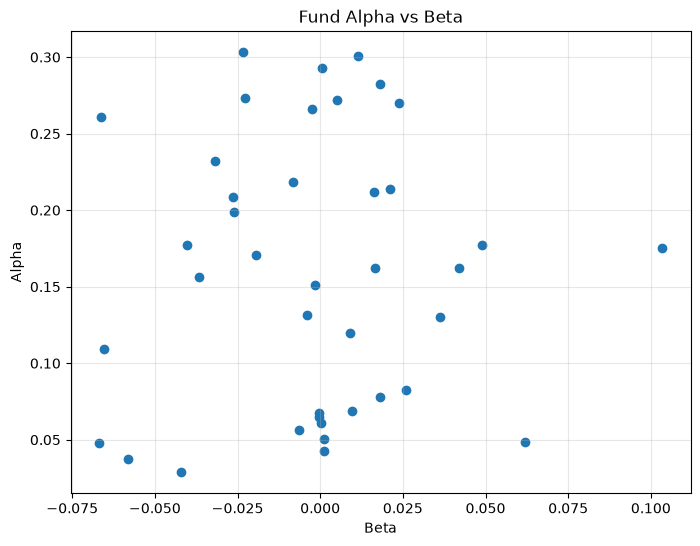

In [143]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    alpha_beta_df["Beta"],
    alpha_beta_df["Alpha"]
)

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Fund Alpha vs Beta")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/charts/alpha_vs_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [151]:
benchmark.groupby("index_name")["date"].agg(["min", "max", "count"])

,min,max,count
index_name,,,
BSE_SMALLCAP,2022-01-03,2026-05-29,1150
CRISIL_GILT,2022-01-03,2026-05-29,1150
CRISIL_LIQUID,2022-01-03,2026-05-29,1150
NIFTY100,2022-01-03,2026-05-29,1150
NIFTY50,2022-01-03,2026-05-29,1150
NIFTY500,2022-01-03,2026-05-29,1150
NIFTY_MIDCAP150,2022-01-03,2026-05-29,1150


In [156]:
print(merged_returns.shape)

merged_returns[
    ["date", "daily_return", "benchmark_return"]
].head(10)

(45960, 5)


,date,daily_return,benchmark_return
0,2022-01-04,-0.010306,-0.013540
1,2022-01-05,0.012865,0.004003
2,2022-01-06,-0.011377,-0.002935
3,2022-01-07,-0.001210,0.006150
4,2022-01-10,-0.008639,-0.008351
5,2022-01-11,0.005562,0.004942
6,2022-01-12,-0.002404,0.009128
7,2022-01-13,-0.004050,0.003746
8,2022-01-14,0.008073,-0.014098
9,2022-01-17,0.000776,0.020825


In [161]:
def calculate_max_drawdown(group):
    """
    Calculate maximum drawdown and identify the drawdown period.
    """
    group = group.sort_values("date").copy()

    # Running peak NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = group["nav"] / group["running_max"] - 1

    # Maximum drawdown value
    max_dd = group["drawdown"].min()

    # End of maximum drawdown
    end_idx = group["drawdown"].idxmin()
    end_date = group.loc[end_idx, "date"]

    # Peak before the drawdown
    peak_idx = group.loc[:end_idx, "nav"].idxmax()
    start_date = group.loc[peak_idx, "date"]

    return {
        "Max_Drawdown": max_dd * 100,
        "Drawdown_Start": start_date,
        "Drawdown_End": end_date
    }

In [166]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    result = calculate_max_drawdown(group)

    result["amfi_code"] = code

    drawdown_results.append(result)

drawdown_df = pd.DataFrame(drawdown_results)

In [171]:
drawdown_df = drawdown_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

drawdown_df = drawdown_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "Max_Drawdown",
        "Drawdown_Start",
        "Drawdown_End"
    ]
]

In [176]:
drawdown_df = (
    drawdown_df
    .sort_values("Max_Drawdown")
    .reset_index(drop=True)
)

drawdown_df.head(10)

,amfi_code,scheme_name,fund_house,Max_Drawdown,Drawdown_Start,Drawdown_End
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-52.574221,2023-01-17,2025-10-28
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-51.677754,2025-05-22,2026-05-11
2,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-35.446916,2024-11-21,2026-05-11
3,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,-31.171900,2024-05-03,2025-01-03
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,-28.706006,2024-08-28,2025-05-14
5,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,-28.001124,2025-01-07,2026-04-27
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,-24.734441,2022-03-30,2022-09-15
7,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,-24.003511,2023-11-09,2024-10-17
8,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-23.344886,2025-04-09,2026-02-20
9,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,-21.751396,2022-02-24,2023-05-22


In [181]:
drawdown_df.to_csv(
    "../outputs/reports/max_drawdown.csv",
    index=False
)

print("✅ Maximum Drawdown report saved.")

✅ Maximum Drawdown report saved.


In [186]:
import os

print(os.getcwd())

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\notebooks


In [191]:
import os

print(os.listdir("../outputs/reports"))

['alpha_beta.csv', 'cagr_comparison.csv', 'max_drawdown.csv', 'sharpe_ratio.csv', 'sortino_ratio.csv']


In [196]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\notebooks


In [201]:
import os

print(os.path.abspath("../outputs/reports"))

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\outputs\reports


In [206]:
scorecard = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "CAGR_3Y"
    ]
].copy()

scorecard = scorecard.merge(
    sharpe_df[
        [
            "amfi_code",
            "Sharpe_Ratio"
        ]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        [
            "amfi_code",
            "Alpha"
        ]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[
        [
            "amfi_code",
            "Max_Drawdown"
        ]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,CAGR_3Y,Sharpe_Ratio,Alpha,Max_Drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.292353,-0.201517,0.037476,-24.734441,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,3.915479,-0.567095,0.042818,-4.308264,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.433971,1.093699,0.271954,-16.217209,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.960211,1.027213,0.213998,-11.291596,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-4.151454,0.162661,0.108971,-35.446916,1.53


In [211]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(
    ascending=False
)

In [216]:
n = len(scorecard)

def rank_to_score(rank):
    return (n - rank) / (n - 1) * 100

scorecard["Return_Score"] = rank_to_score(scorecard["Return_Rank"])

scorecard["Sharpe_Score"] = rank_to_score(scorecard["Sharpe_Rank"])

scorecard["Alpha_Score"] = rank_to_score(scorecard["Alpha_Rank"])

scorecard["Expense_Score"] = rank_to_score(scorecard["Expense_Rank"])

scorecard["Drawdown_Score"] = rank_to_score(scorecard["Drawdown_Rank"])

In [221]:
scorecard["Fund_Score"] = (

      0.30 * scorecard["Return_Score"]

    + 0.25 * scorecard["Sharpe_Score"]

    + 0.20 * scorecard["Alpha_Score"]

    + 0.15 * scorecard["Expense_Score"]

    + 0.10 * scorecard["Drawdown_Score"]

)

In [226]:
scorecard = (
    scorecard
    .sort_values(
        "Fund_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,CAGR_3Y,Sharpe_Ratio,Alpha,Max_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,33.991970,1.448291,0.269838,-11.265729,1.46,2.0,1.0,7.0,23.0,8.0,97.435897,100.000000,84.615385,43.589744,82.051282,85.897436
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.769243,1.180101,0.292636,-18.188514,1.36,5.0,5.0,3.0,15.0,25.0,89.743590,89.743590,94.871795,64.102564,38.461538,81.794872
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,29.575111,1.306744,0.273305,-12.973968,1.45,7.0,2.0,5.0,22.0,13.0,84.615385,97.435897,89.743590,46.153846,69.230769,81.538462
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.433971,1.093699,0.271954,-16.217209,1.38,4.0,7.0,6.0,17.0,20.0,92.307692,84.615385,87.179487,58.974359,51.282051,80.256410
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.478927,1.026524,0.211948,-12.588276,0.80,3.0,10.0,13.0,12.0,12.0,94.871795,76.923077,69.230769,71.794872,71.794872,79.487179
5,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,35.102528,0.998231,0.260767,-20.960884,1.38,1.0,11.0,9.0,17.0,28.0,100.000000,74.358974,79.487179,58.974359,30.769231,76.410256
6,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,30.448613,1.208267,0.232010,-15.012385,1.54,6.0,4.0,10.0,30.5,17.0,87.179487,92.307692,76.923077,24.358974,58.974359,74.166667
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,29.171358,1.234930,0.282704,-16.396743,1.60,8.0,3.0,4.0,36.5,21.0,82.051282,94.871795,92.307692,8.974359,48.717949,73.012821
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.960211,1.027213,0.213998,-11.291596,1.60,9.0,9.0,12.0,36.5,9.0,79.487179,79.487179,71.794872,8.974359,79.487179,67.371795
9,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,26.663091,0.945308,0.303370,-28.706006,1.43,12.0,14.0,1.0,21.0,36.0,71.794872,66.666667,100.000000,48.717949,10.256410,66.538462


In [232]:
scorecard.to_csv(
    "../outputs/reports/fund_scorecard.csv",
    index=False
)

print("✅ fund_scorecard.csv saved successfully.")

✅ fund_scorecard.csv saved successfully.


NameError: name 'CHARTS_DIR' is not defined

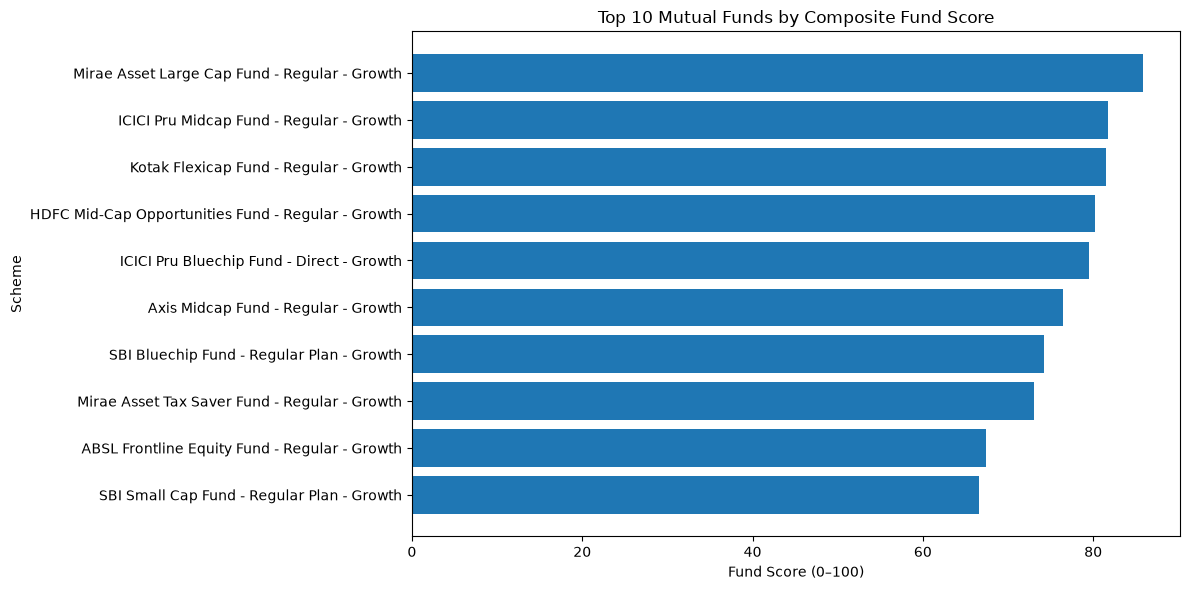

In [237]:
top10 = (
    scorecard
    .head(10)
    .sort_values("Fund_Score")
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by Composite Fund Score")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "fund_scorecard_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

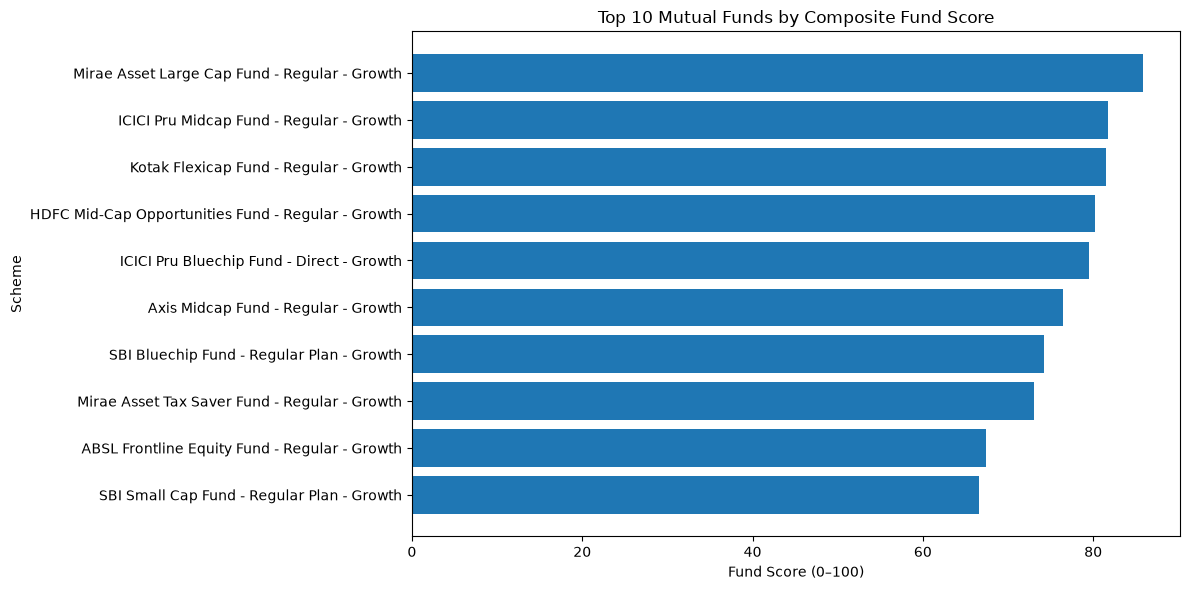

✅ Chart saved successfully.


In [238]:
top10 = (
    scorecard
    .head(10)
    .sort_values("Fund_Score")
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by Composite Fund Score")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/fund_scorecard_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved successfully.")

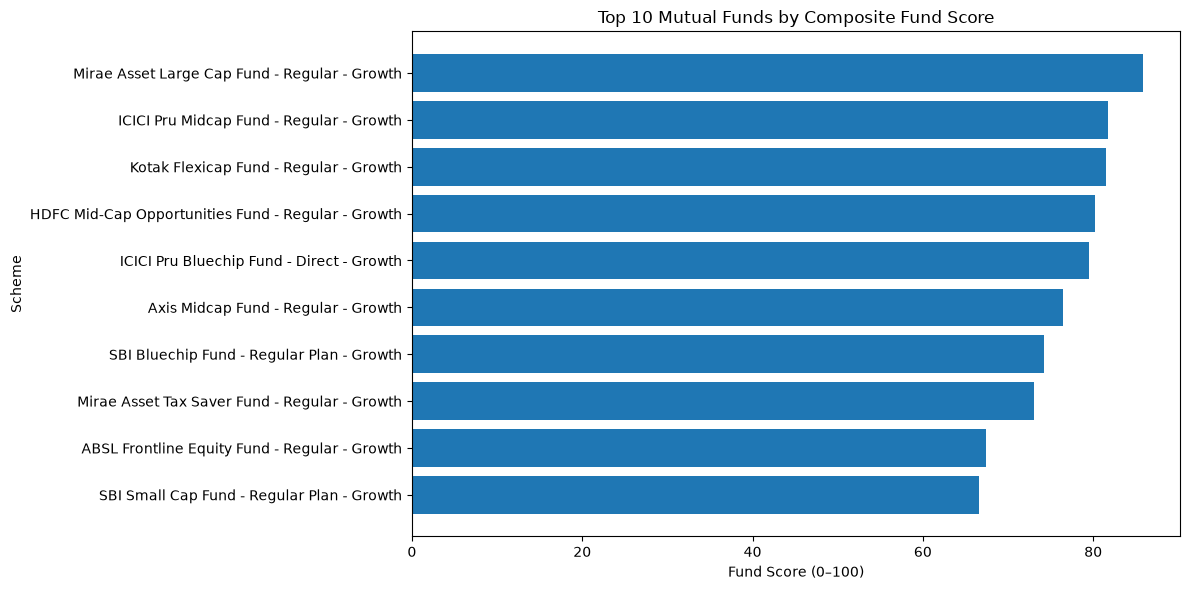

✅ Chart saved successfully.


In [243]:
top10 = (
    scorecard
    .head(10)
    .sort_values("Fund_Score")
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Funds by Composite Fund Score")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/fund_scorecard_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved successfully.")

In [248]:
from pandas.tseries.offsets import DateOffset

end_date = nav["date"].max()
start_date = end_date - DateOffset(years=3)

nav_3yr = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

print(nav_3yr.head())

TypeError: unsupported operand type(s) for -: 'str' and 'DateOffset'

In [249]:
print(nav.dtypes)


amfi_code      int64
date             str
nav          float64
dtype: object


In [254]:
import pandas as pd

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.dtypes)
print(benchmark.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object
date           datetime64[us]
index_name                str
close_value           float64
dtype: object


In [259]:
import pandas as pd

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.dtypes)
print(benchmark.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object
date           datetime64[us]
index_name                str
close_value           float64
dtype: object


In [264]:
normalized_funds = []

for code, group in nav_3yr.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    base_nav = group["nav"].iloc[0]

    group["normalized_nav"] = (
        group["nav"] / base_nav
    ) * 100

    normalized_funds.append(group)

normalized_funds = pd.concat(
    normalized_funds,
    ignore_index=True
)

normalized_funds.head()

NameError: name 'nav_3yr' is not defined

In [265]:
from pandas.tseries.offsets import DateOffset

# Ensure date columns are datetime
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Latest available date
end_date = nav["date"].max()

# Three years before latest date
start_date = end_date - DateOffset(years=3)

# Filter Top 5 funds for last 3 years
nav_3yr = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

print("Start Date :", start_date)
print("End Date   :", end_date)
print("Shape      :", nav_3yr.shape)
print(nav_3yr.head())

NameError: name 'top5_codes' is not defined

In [266]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

print("Top 5 AMFI Codes:")
print(top5_codes)

Top 5 AMFI Codes:
[148567, 120505, 120843, 100033, 120504]


In [271]:
from pandas.tseries.offsets import DateOffset

# Ensure dates are datetime
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

end_date = nav["date"].max()
start_date = end_date - DateOffset(years=3)

nav_3yr = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

print("Start Date:", start_date)
print("End Date:", end_date)
print("Shape:", nav_3yr.shape)

nav_3yr.head()

Start Date: 2023-05-29 00:00:00
End Date: 2026-05-29 00:00:00
Shape: (3925, 3)


,amfi_code,date,nav
2665,100033,2023-05-29,147.2155
2666,100033,2023-05-30,147.2007
2667,100033,2023-05-31,147.4640
2668,100033,2023-06-01,146.5954
2669,100033,2023-06-02,145.8015


In [276]:
normalized_funds = []

for code, group in nav_3yr.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    base_nav = group["nav"].iloc[0]

    group["normalized_nav"] = (
        group["nav"] / base_nav
    ) * 100

    normalized_funds.append(group)

normalized_funds = pd.concat(
    normalized_funds,
    ignore_index=True
)

print(normalized_funds.head())
print("Shape:", normalized_funds.shape)

   amfi_code       date       nav  normalized_nav
0     100033 2023-05-29  147.2155      100.000000
1     100033 2023-05-30  147.2007       99.989947
2     100033 2023-05-31  147.4640      100.168800
3     100033 2023-06-01  146.5954       99.578781
4     100033 2023-06-02  145.8015       99.039503
Shape: (3925, 4)


In [776]:
from pathlib import Path

processed_path = Path("data/processed")

files = list(processed_path.glob("*.csv"))

for f in files:
    print(f.name)

In [775]:
benchmark_3yr = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_3yr = benchmark_3yr[
    benchmark_3yr["date"] >= start_date
]

print(benchmark_3yr.head())
print("Shape:", benchmark_3yr.shape)

TypeError: '<=' not supported between instances of 'Timestamp' and 'str'

In [ ]:
benchmark_3yr = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_3yr = benchmark_3yr[
    benchmark_3yr["date"] >= start_date
]

print(benchmark_3yr.head())
print("Shape:", benchmark_3yr.shape)

TypeError: '<=' not supported between instances of 'Timestamp' and 'str'

In [ ]:
print(benchmark.dtypes)
print(type(benchmark["date"].iloc[0]))
print(benchmark["date"].head())

date               str
index_name         str
close_value    float64
dtype: object
<class 'str'>
0    2022-01-03
1    2022-01-04
2    2022-01-05
3    2022-01-06
4    2022-01-07
Name: date, dtype: str


In [ ]:
print(type(start_date))

<class 'pandas.Timestamp'>


In [ ]:
import pandas as pd

benchmark["date"] = pd.to_datetime(benchmark["date"])
nav["date"] = pd.to_datetime(nav["date"])

print(benchmark.dtypes)
print(nav.dtypes)

date           datetime64[us]
index_name                str
close_value           float64
dtype: object
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [ ]:

import pandas as pd
import numpy as np

# -----------------------------
# Load datasets (with proper parsing)
# -----------------------------

nav = pd.read_csv(
    "../data/processed/nav_history.csv",
    parse_dates=["date"]
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices.csv",
    parse_dates=["date"]
)

fund = pd.read_csv(
    "../data/processed/fund_master.csv"
)

scheme_performance = pd.read_csv(
    "../data/processed/scheme_performance.csv"
)

# -----------------------------
# Safety checks
# -----------------------------

print("NAV dtypes:")
print(nav.dtypes, "\n")

print("Benchmark dtypes:")
print(benchmark.dtypes, "\n")

print("Fund Master dtypes:")
print(fund.dtypes, "\n")

# -----------------------------
# Basic sanity checks
# -----------------------------

print("NAV rows:", nav.shape)
print("Benchmark rows:", benchmark.shape)
print("Funds:", fund.shape)

NAV dtypes:
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object 

Benchmark dtypes:
date           datetime64[us]
index_name                str
close_value           float64
dtype: object 

Fund Master dtypes:
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object 

NAV rows: (46000, 3)
Benchmark rows: (8050, 3)
Funds: (40, 15)


In [ ]:
benchmark_3yr = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_3yr = benchmark_3yr[
    benchmark_3yr["date"] >= start_date
]

TypeError: '<=' not supported between instances of 'Timestamp' and 'str'

In [ ]:
print("Benchmark dtype BEFORE fix:")
print(benchmark.dtypes)

print("\nSample value type:")
print(type(benchmark["date"].iloc[0]))
print("\nSample value:")
print(benchmark["date"].iloc[0])

Benchmark dtype BEFORE fix:
date               str
index_name         str
close_value    float64
dtype: object

Sample value type:
<class 'str'>

Sample value:
2022-01-03


In [ ]:
benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")
nav["date"] = pd.to_datetime(nav["date"], errors="coerce")

print("AFTER FIX:")
print(benchmark.dtypes)
print(nav.dtypes)

print("\nCheck types:")
print(type(benchmark["date"].iloc[0]))
print(type(nav["date"].iloc[0]))

AFTER FIX:
date           datetime64[us]
index_name                str
close_value           float64
dtype: object
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

Check types:
<class 'pandas.Timestamp'>
<class 'pandas.Timestamp'>


In [ ]:
benchmark_normalized = []

for index_name, group in benchmark_3yr.groupby("index_name"):

    group = group.sort_values("date").copy()

    base_value = group["close_value"].iloc[0]

    group["normalized_close"] = (
        group["close_value"] / base_value
    ) * 100

    benchmark_normalized.append(group)

benchmark_normalized = pd.concat(
    benchmark_normalized,
    ignore_index=True
)

print(benchmark_normalized.head())
print("Shape:", benchmark_normalized.shape)

         date index_name  close_value  normalized_close
0  2022-01-03   NIFTY100     17778.24        100.000000
1  2022-01-04   NIFTY100     17537.52         98.645985
2  2022-01-05   NIFTY100     17607.73         99.040906
3  2022-01-06   NIFTY100     17556.05         98.750214
4  2022-01-07   NIFTY100     17664.02         99.357529
Shape: (2300, 4)


C:\Users\Amit Singh\AppData\Local\Temp\ipykernel_18680\2137193482.py:27: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(


ConversionError: Failed to convert value(s) to axis units: array(['2023-05-29T00:00:00.000000', '2023-05-30T00:00:00.000000',
       '2023-05-31T00:00:00.000000', '2023-06-01T00:00:00.000000',
       '2023-06-02T00:00:00.000000', '2023-06-05T00:00:00.000000',
       '2023-06-06T00:00:00.000000', '2023-06-07T00:00:00.000000',
       '2023-06-08T00:00:00.000000', '2023-06-09T00:00:00.000000',
       '2023-06-12T00:00:00.000000', '2023-06-13T00:00:00.000000',
       '2023-06-14T00:00:00.000000', '2023-06-15T00:00:00.000000',
       '2023-06-16T00:00:00.000000', '2023-06-19T00:00:00.000000',
       '2023-06-20T00:00:00.000000', '2023-06-21T00:00:00.000000',
       '2023-06-22T00:00:00.000000', '2023-06-23T00:00:00.000000',
       '2023-06-26T00:00:00.000000', '2023-06-27T00:00:00.000000',
       '2023-06-28T00:00:00.000000', '2023-06-29T00:00:00.000000',
       '2023-06-30T00:00:00.000000', '2023-07-03T00:00:00.000000',
       '2023-07-04T00:00:00.000000', '2023-07-05T00:00:00.000000',
   

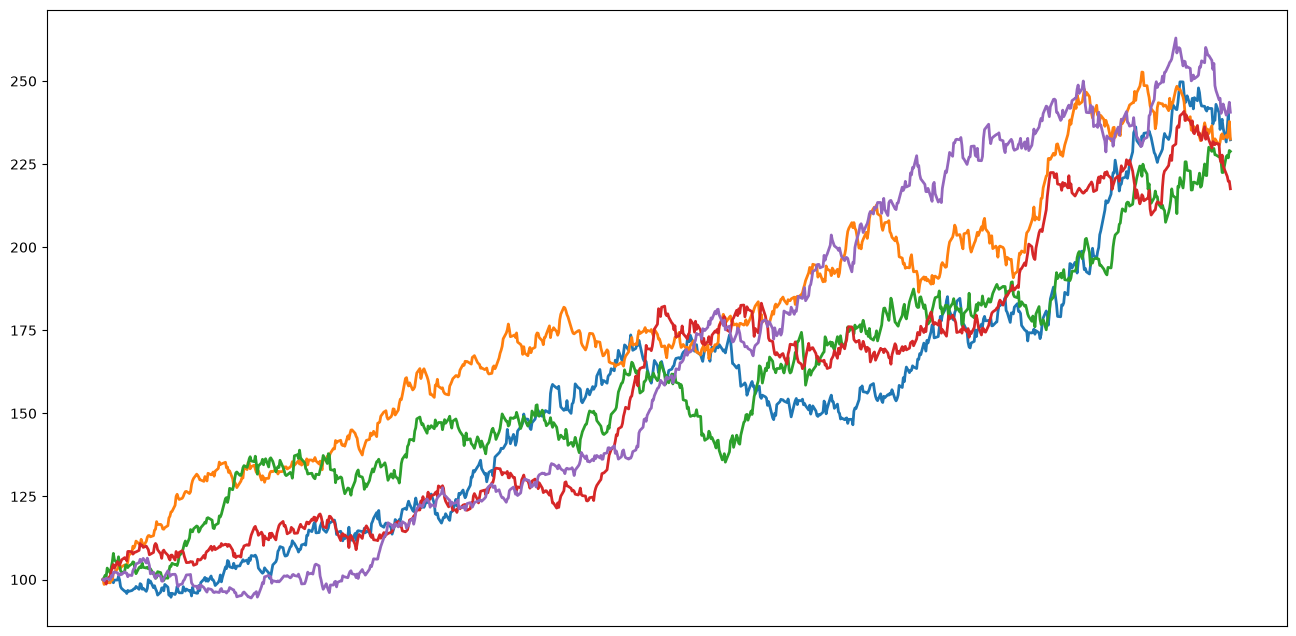

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# -----------------------------
# Plot Top 5 Funds
# -----------------------------
for code, group in normalized_funds.groupby("amfi_code"):

    scheme_name = fund.loc[
        fund["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        group["date"],
        group["normalized_nav"],
        label=scheme_name,
        linewidth=2
    )

# -----------------------------
# Plot Benchmarks
# -----------------------------
for index_name, group in benchmark_normalized.groupby("index_name"):

    plt.plot(
        group["date"],
        group["normalized_close"],
        linestyle="--",
        linewidth=3,
        label=index_name
    )

# -----------------------------
# Styling
# -----------------------------
plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Growth (Base = 100)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout()

# -----------------------------
# Save Output
# -----------------------------
plt.savefig(
    "../outputs/charts/top5_vs_benchmark_3yr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Benchmark comparison chart saved successfully")

In [ ]:
benchmark_3yr = benchmark.copy()

benchmark_3yr = benchmark_3yr[
    benchmark_3yr["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_3yr = benchmark_3yr[
    benchmark_3yr["date"] >= start_date
]

print(benchmark_3yr.head())
print("Shape:", benchmark_3yr.shape)

TypeError: '<=' not supported between instances of 'Timestamp' and 'str'

C:\Users\Amit Singh\AppData\Local\Temp\ipykernel_18680\2137193482.py:27: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(


ConversionError: Failed to convert value(s) to axis units: array(['2023-05-29T00:00:00.000000', '2023-05-30T00:00:00.000000',
       '2023-05-31T00:00:00.000000', '2023-06-01T00:00:00.000000',
       '2023-06-02T00:00:00.000000', '2023-06-05T00:00:00.000000',
       '2023-06-06T00:00:00.000000', '2023-06-07T00:00:00.000000',
       '2023-06-08T00:00:00.000000', '2023-06-09T00:00:00.000000',
       '2023-06-12T00:00:00.000000', '2023-06-13T00:00:00.000000',
       '2023-06-14T00:00:00.000000', '2023-06-15T00:00:00.000000',
       '2023-06-16T00:00:00.000000', '2023-06-19T00:00:00.000000',
       '2023-06-20T00:00:00.000000', '2023-06-21T00:00:00.000000',
       '2023-06-22T00:00:00.000000', '2023-06-23T00:00:00.000000',
       '2023-06-26T00:00:00.000000', '2023-06-27T00:00:00.000000',
       '2023-06-28T00:00:00.000000', '2023-06-29T00:00:00.000000',
       '2023-06-30T00:00:00.000000', '2023-07-03T00:00:00.000000',
       '2023-07-04T00:00:00.000000', '2023-07-05T00:00:00.000000',
   

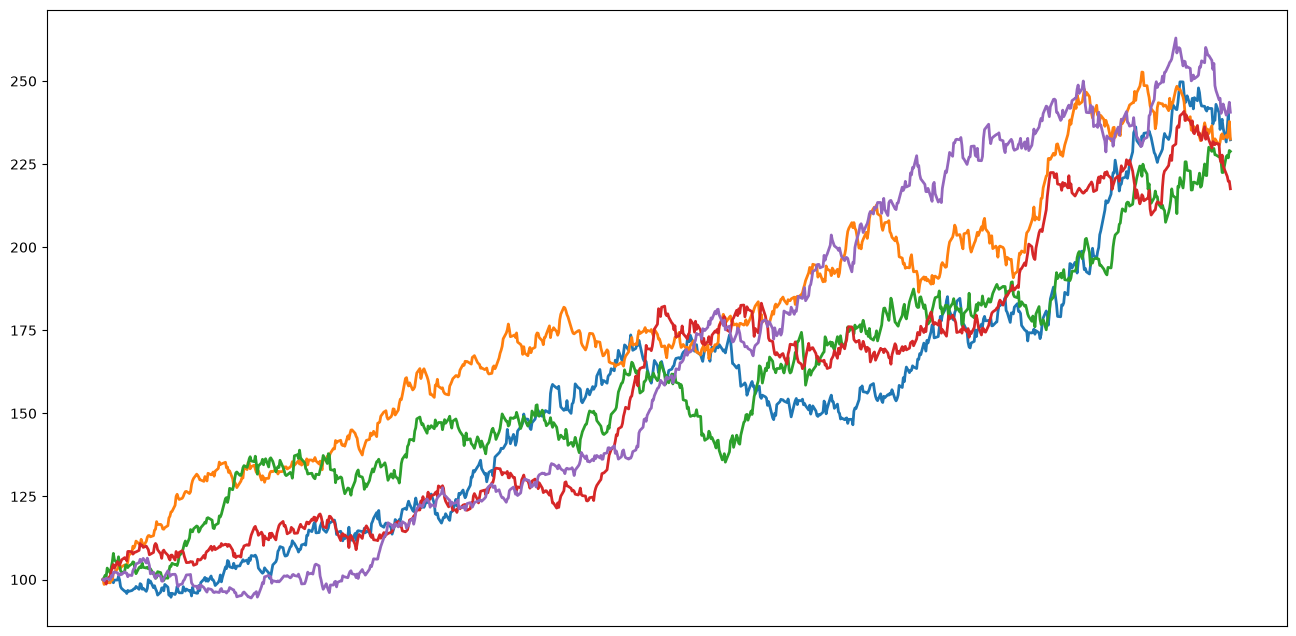

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# -----------------------------
# Plot Top 5 Funds
# -----------------------------
for code, group in normalized_funds.groupby("amfi_code"):

    scheme_name = fund.loc[
        fund["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        group["date"],
        group["normalized_nav"],
        label=scheme_name,
        linewidth=2
    )

# -----------------------------
# Plot Benchmarks
# -----------------------------
for index_name, group in benchmark_normalized.groupby("index_name"):

    plt.plot(
        group["date"],
        group["normalized_close"],
        linestyle="--",
        linewidth=3,
        label=index_name
    )

# -----------------------------
# Styling
# -----------------------------
plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Growth (Base = 100)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)

plt.tight_layout()

# -----------------------------
# Save Output
# -----------------------------
plt.savefig(
    "../outputs/charts/top5_vs_benchmark_3yr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Benchmark comparison chart saved successfully")

In [ ]:

import numpy as np

tracking_error_list = []

# Use NIFTY100 as benchmark
nifty100 = benchmark.copy()
nifty100 = nifty100[nifty100["index_name"] == "NIFTY100"]

# compute returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

for code, group in nav.groupby("amfi_code"):

    merged = group.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    tracking_error_list.append({
        "amfi_code": code,
        "Tracking_Error": (
            (merged["daily_return"] - merged["benchmark_return"])
            .std() * np.sqrt(252)
        )
    })

tracking_error_df = pd.DataFrame(tracking_error_list)

KeyError: 'daily_return'

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# STEP 1: LOAD DATASETS
# -----------------------------

fund_master = pd.read_csv("raw/fund_master.csv")
nav_history = pd.read_csv("raw/nav_history.csv")
benchmark = pd.read_csv("raw/benchmark.csv")
fund_flows = pd.read_csv("raw/fund_flows.csv")
folio_data = pd.read_csv("raw/folio_data.csv")

# -----------------------------
# STEP 1.1: BASIC CHECKS
# -----------------------------

datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "benchmark": benchmark,
    "fund_flows": fund_flows,
    "folio_data": folio_data
}

for name, df in datasets.items():
    print(f"\n📌 {name}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("Missing values:\n", df.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'raw/fund_master.csv'

In [ ]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current Working Directory:
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\notebooks

Files in current directory:
['EDA_Analysis.ipynb', 'Performance_Analytics.ipynb']


In [ ]:
import pandas as pd

fund_master = pd.read_csv("../raw/fund_master.csv")
nav_history = pd.read_csv("../raw/nav_history.csv")
benchmark = pd.read_csv("../raw/benchmark.csv")
fund_flows = pd.read_csv("../raw/fund_flows.csv")
folio_data = pd.read_csv("../raw/folio_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../raw/fund_master.csv'

In [ ]:
import os

base_path = "c:\\College notes\\Internship\\Bluestock Finetech Internship\\MutualFundAnalytics"

for root, dirs, files in os.walk(base_path):
    if "fund_master.csv" in files:
        print("FOUND FUND_MASTER AT:")
        print(root)

FOUND FUND_MASTER AT:
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\processed


In [ ]:
import pandas as pd

BASE_PATH = "../data/processed/"

fund_master = pd.read_csv(BASE_PATH + "fund_master.csv")
nav_history = pd.read_csv(BASE_PATH + "nav_history.csv")
benchmark = pd.read_csv(BASE_PATH + "benchmark.csv")
fund_flows = pd.read_csv(BASE_PATH + "fund_flows.csv")
folio_data = pd.read_csv(BASE_PATH + "folio_data.csv")

datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "benchmark": benchmark,
    "fund_flows": fund_flows,
    "folio_data": folio_data
}

for name, df in datasets.items():
    print(f"\n📌 {name}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/benchmark.csv'

In [ ]:
import os

path = "../data/processed/"

print("Files in processed folder:")
print(os.listdir(path))

Files in processed folder:
['aum_by_fund_house.csv', 'benchmark_indices.csv', 'category_inflows.csv', 'fund_master.csv', 'industry_folio_count.csv', 'investor_transactions.csv', 'monthly_sip_inflows.csv', 'nav_history.csv', 'portfolio_holdings.csv', 'scheme_performance.csv']


In [ ]:
import pandas as pd

BASE_PATH = "../data/processed/"

# -------------------------
# CORE DATASETS
# -------------------------
fund_master = pd.read_csv(BASE_PATH + "fund_master.csv")
nav_history = pd.read_csv(BASE_PATH + "nav_history.csv")
benchmark = pd.read_csv(BASE_PATH + "benchmark_indices.csv")
scheme_performance = pd.read_csv(BASE_PATH + "scheme_performance.csv")

# -------------------------
# FLOW DATASETS
# -------------------------
investor_transactions = pd.read_csv(BASE_PATH + "investor_transactions.csv")
monthly_sip_inflows = pd.read_csv(BASE_PATH + "monthly_sip_inflows.csv")
category_inflows = pd.read_csv(BASE_PATH + "category_inflows.csv")

# -------------------------
# INDUSTRY DATASETS
# -------------------------
aum_by_fund_house = pd.read_csv(BASE_PATH + "aum_by_fund_house.csv")
industry_folio_count = pd.read_csv(BASE_PATH + "industry_folio_count.csv")
portfolio_holdings = pd.read_csv(BASE_PATH + "portfolio_holdings.csv")

# -------------------------
# QUICK VALIDATION
# -------------------------
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "benchmark": benchmark,
    "scheme_performance": scheme_performance,
    "investor_transactions": investor_transactions,
    "monthly_sip_inflows": monthly_sip_inflows,
    "category_inflows": category_inflows,
    "aum_by_fund_house": aum_by_fund_house,
    "industry_folio_count": industry_folio_count,
    "portfolio_holdings": portfolio_holdings
}

for name, df in datasets.items():
    print(f"\n📌 {name}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))


📌 fund_master
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

📌 nav_history
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']

📌 benchmark
Shape: (8050, 3)
Columns: ['date', 'index_name', 'close_value']

📌 scheme_performance
Shape: (40, 20)
Columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_anomaly']

📌 investor_transactions
Shape: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh',

In [ ]:
import pandas as pd
import numpy as np

def standardize_dates(df):
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def standardize_numeric(df):
    for col in df.columns:
        if df[col].dtype == "object":
            # try convert numeric-like columns
            df[col] = pd.to_numeric(df[col], errors="ignore")
    return df

In [ ]:
all_dfs = [
    fund_master,
    nav_history,
    benchmark,
    scheme_performance,
    investor_transactions,
    monthly_sip_inflows,
    category_inflows,
    aum_by_fund_house,
    industry_folio_count,
    portfolio_holdings
]

cleaned_dfs = []

for df in all_dfs:
    df = standardize_dates(df)
    df = standardize_numeric(df)
    cleaned_dfs.append(df)

# reassign back
(
fund_master,
nav_history,
benchmark,
scheme_performance,
investor_transactions,
monthly_sip_inflows,
category_inflows,
aum_by_fund_house,
industry_folio_count,
portfolio_holdings
) = cleaned_dfs

In [ ]:
print("🔍 DATA TYPE CHECK AFTER STANDARDIZATION\n")

for name, df in {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "benchmark": benchmark,
    "scheme_performance": scheme_performance
}.items():
    print(f"\n📌 {name}")
    print(df.dtypes)

🔍 DATA TYPE CHECK AFTER STANDARDIZATION


📌 fund_master
amfi_code                      int64
fund_house                       str
scheme_name                      str
category                         str
sub_category                     str
plan                             str
launch_date           datetime64[us]
benchmark                        str
expense_ratio_pct            float64
exit_load_pct                float64
min_sip_amount                 int64
min_lumpsum_amount             int64
fund_manager                     str
risk_category                    str
sebi_category_code               str
dtype: object

📌 nav_history
amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

📌 benchmark
date               str
index_name         str
close_value    float64
dtype: object

📌 scheme_performance
amfi_code               int64
scheme_name               str
fund_house                str
category                  str
plan                    

In [ ]:
print("FUND MASTER COLUMNS:")
print(fund_master.columns)

print("\nNAV HISTORY COLUMNS:")
print(nav_history.columns)

FUND MASTER COLUMNS:
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

NAV HISTORY COLUMNS:
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [ ]:
if "amfi_code" in fund_master.columns and "amfi_code" in nav_history.columns:
    fund_nav = pd.merge(
        nav_history,
        fund_master,
        on="amfi_code",
        how="left"
    )
    print("✅ Merge successful")
else:
    print("❌ amfi_code not found — check column names")

✅ Merge successful


In [ ]:
print("Shape:", fund_nav.shape)
print("\nColumns:")
print(fund_nav.columns)

print("\nMissing values check:")
print(fund_nav.isnull().sum().sort_values(ascending=False).head(10))

Shape: (46000, 17)

Columns:
Index(['amfi_code', 'date', 'nav', 'fund_house', 'scheme_name', 'category',
       'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

Missing values check:
amfi_code       0
date            0
nav             0
fund_house      0
scheme_name     0
category        0
sub_category    0
plan            0
launch_date     0
benchmark       0
dtype: int64


In [ ]:
fund_nav.columns

Index(['amfi_code', 'date', 'nav', 'fund_house', 'scheme_name', 'category',
       'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [ ]:
fund_nav = fund_nav.sort_values(["amfi_code", "date"])
fund_nav = fund_nav.dropna(subset=["nav", "date"])

In [ ]:
fund_nav["daily_return"] = fund_nav.groupby("amfi_code")["nav"].pct_change()

In [ ]:
fund_nav["nav_30d_ago"] = fund_nav.groupby("amfi_code")["nav"].shift(30)

fund_nav["return_30d"] = (
    fund_nav["nav"] / fund_nav["nav_30d_ago"] - 1
)

In [ ]:
fund_nav["nav_90d_ago"] = fund_nav.groupby("amfi_code")["nav"].shift(90)

fund_nav["return_90d"] = (
    fund_nav["nav"] / fund_nav["nav_90d_ago"] - 1
)

In [ ]:
fund_nav["nav_365d_ago"] = fund_nav.groupby("amfi_code")["nav"].shift(365)

fund_nav["return_1y"] = (
    fund_nav["nav"] / fund_nav["nav_365d_ago"] - 1
)

In [ ]:
print("📊 Sample Performance Data")
display(
    fund_nav[[
        "amfi_code",
        "date",
        "nav",
        "daily_return",
        "return_30d",
        "return_90d",
        "return_1y"
    ]].head(10)
)

📊 Sample Performance Data


,amfi_code,date,nav,daily_return,return_30d,return_90d,return_1y
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN
6,100016,2022-01-11,513.5542,0.005562,NaN,NaN,NaN
7,100016,2022-01-12,512.3195,-0.002404,NaN,NaN,NaN
8,100016,2022-01-13,510.2445,-0.004050,NaN,NaN,NaN
9,100016,2022-01-14,514.3636,0.008073,NaN,NaN,NaN


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum_by_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
print(aum_by_fund_house.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [ ]:
aum_by_fund_house.columns = aum_by_fund_house.columns.str.lower()

# standard naming safety
aum_by_fund_house = aum_by_fund_house.rename(columns={
    "fundhouse": "fund_house",
    "aum_cr": "aum",
    "aum (cr)": "aum"
})

In [ ]:
aum_pivot = aum_by_fund_house.pivot_table(
    index="fund_house",
    columns="year",
    values="aum",
    aggfunc="sum"
)

aum_pivot = aum_pivot.fillna(0)

aum_pivot.head()

KeyError: 'aum'

In [ ]:
print(aum_by_fund_house.columns.tolist())


['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [ ]:
aum_by_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
aum_by_fund_house["date"] = pd.to_datetime(aum_by_fund_house["date"])

aum_by_fund_house["year"] = aum_by_fund_house["date"].dt.year

In [ ]:
aum_pivot = aum_by_fund_house.pivot_table(
    index="fund_house",
    columns="year",
    values="aum_crore",
    aggfunc="sum"
)

aum_pivot = aum_pivot.fillna(0)

aum_pivot.head()

year,2022,2023,2024,2025
fund_house,,,,
Aditya Birla Sun Life MF,563000,583000,1086000,845000
Axis Mutual Fund,490000,501000,870000,660000
DSP Mutual Fund,222000,247000,515000,425000
HDFC Mutual Fund,880000,985000,2142000,1725000
ICICI Prudential MF,953000,1090000,2296000,1954000


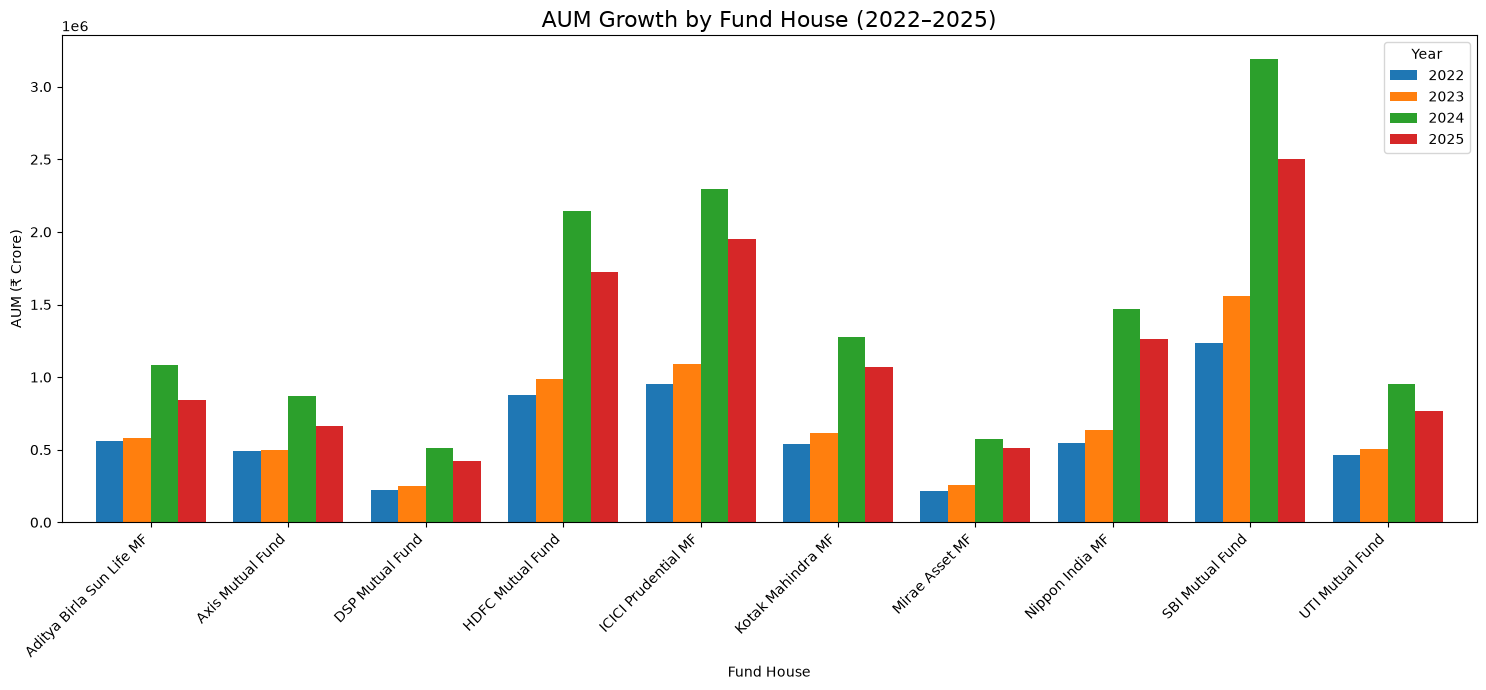

In [ ]:
import matplotlib.pyplot as plt

ax = aum_pivot.plot(
    kind="bar",
    figsize=(15,7),
    width=0.8
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")

plt.tight_layout()
plt.show()

In [ ]:
aum_by_fund_house[
    aum_by_fund_house["fund_house"] == "SBI Mutual Fund"
].sort_values("date")


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


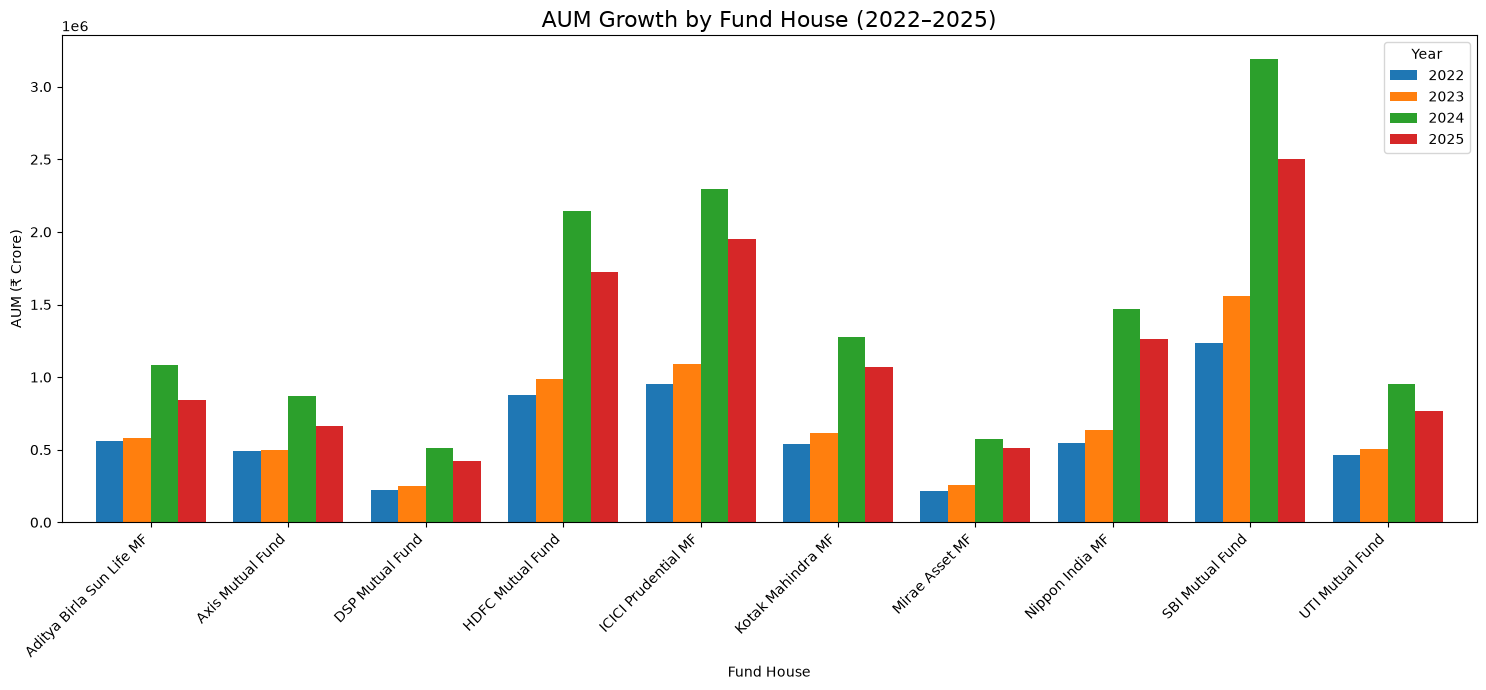

✅ Chart saved to: ../outputs/charts/aum_growth_by_fund_house_2022_2025.png


In [ ]:
import os
import matplotlib.pyplot as plt

# Create output folder if it doesn't exist
os.makedirs("../outputs/charts", exist_ok=True)

ax = aum_pivot.plot(
    kind="bar",
    figsize=(15, 7),
    width=0.8
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")

plt.tight_layout()

# Save chart
plt.savefig(
    "../outputs/charts/aum_growth_by_fund_house_2022_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ Chart saved to: ../outputs/charts/aum_growth_by_fund_house_2022_2025.png")

In [ ]:
monthly_sip_inflows.columns.tolist()

['month',
 'sip_inflow_crore',
 'active_sip_accounts_crore',
 'new_sip_accounts_lakh',
 'sip_aum_lakh_crore',
 'yoy_growth_pct']

In [ ]:
monthly_sip_inflows.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Convert month to datetime
monthly_sip_inflows["month"] = pd.to_datetime(
    monthly_sip_inflows["month"],
    format="%Y-%m"
)

monthly_sip_inflows = monthly_sip_inflows.sort_values("month")

In [ ]:
peak = monthly_sip_inflows.loc[
    monthly_sip_inflows["sip_inflow_crore"].idxmax()
]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [ ]:
fig = px.line(
    monthly_sip_inflows,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight peak
fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text=f"Peak: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    title_x=0.5
)

fig.show()

In [ ]:
import os

os.makedirs("../outputs/charts", exist_ok=True)

fig.write_html("../outputs/charts/sip_inflow_time_series_2022_2025.html")

print("✅ Interactive chart saved.")

✅ Interactive chart saved.


In [ ]:
# Requires: pip install kaleido

fig.write_image(
    "../outputs/charts/sip_inflow_time_series_2022_2025.png",
    width=1400,
    height=700,
    scale=2
)

print("✅ PNG saved successfully.")

TypeError: Type is not JSON serializable: Timestamp

In [ ]:
fig = px.line(
    monthly_sip_inflows,
    x="month_label",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={
        "month_label": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

fig.add_annotation(
    x=peak["month"].strftime("%b %Y"),
    y=peak["sip_inflow_crore"],
    text=f"Peak: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'] but received: month_label

In [ ]:
import plotly
import kaleido

print(plotly.__version__)
print(kaleido.__version__)

6.8.0


AttributeError: module 'kaleido' has no attribute '__version__'

In [ ]:
import plotly
import importlib.metadata

print("Plotly :", plotly.__version__)
print("Kaleido:", importlib.metadata.version("kaleido"))

Plotly : 6.8.0
Kaleido: 1.3.0


In [ ]:
fig.to_dict()["data"][0]["x"][:5]


array(['2022-01-01T00:00:00.000000', '2022-02-01T00:00:00.000000',
       '2022-03-01T00:00:00.000000', '2022-04-01T00:00:00.000000',
       '2022-05-01T00:00:00.000000'], dtype='datetime64[us]')

In [ ]:
# Create display labels
monthly_sip_inflows["month_str"] = monthly_sip_inflows["month"].dt.strftime("%Y-%m")

In [ ]:
fig = px.line(
    monthly_sip_inflows,
    x="month_str",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={
        "month_str": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

fig.add_annotation(
    x=peak["month"].strftime("%Y-%m"),
    y=peak["sip_inflow_crore"],
    text=f"Peak: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_tickangle=-45
)

In [ ]:
fig.write_image(
    "../outputs/charts/sip_inflow_time_series_2022_2025.png",
    width=1400,
    height=700,
    scale=2
)

In [ ]:
print(investor_transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


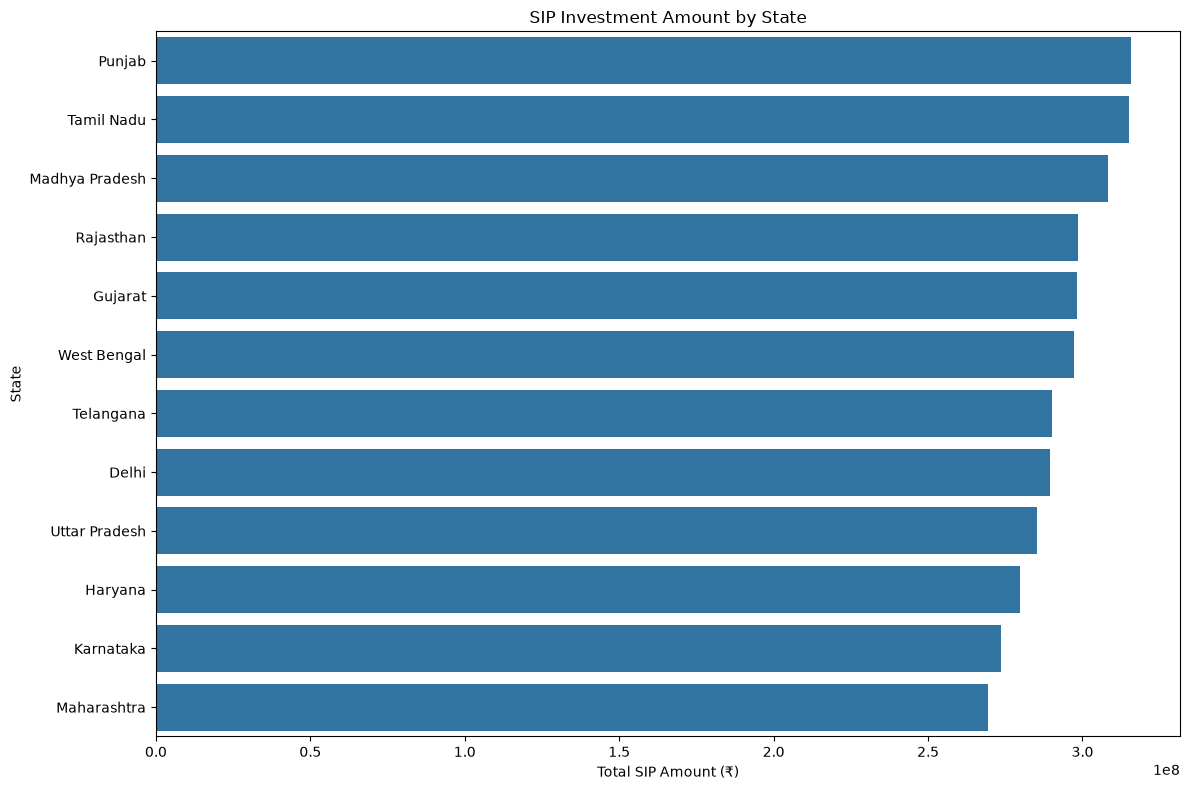

✅ geographic_distribution_state.png saved


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../outputs/charts", exist_ok=True)

# Aggregate SIP amount by state
state_sip = (
    investor_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("SIP Investment Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/geographic_distribution_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("✅ geographic_distribution_state.png saved")

### Insight 1: Overall NAV Growth

Most mutual fund schemes exhibited a long-term upward NAV trend between 2022 and 2025, reflecting sustained market growth despite periods of volatility. This indicates consistent value appreciation across diversified equity funds.

**Supporting Chart:** NAV Trend Analysis (2022–2025)

### Insight 2: Bull Run and Market Correction

A strong upward trend was observed during 2023, while a noticeable correction occurred during 2024 before markets resumed growth. This demonstrates the cyclical nature of equity markets.

**Supporting Chart:** NAV Trend Analysis (2022–2025)

### Insight 3: Fund House AUM Expansion

Assets Under Management (AUM) increased steadily across major fund houses from 2022 to 2025, indicating growing investor participation in mutual funds.

**Supporting Chart:** AUM Growth by Fund House

### Insight 4: SBI Maintained Market Leadership

SBI Mutual Fund consistently maintained the highest AUM among the analyzed fund houses, demonstrating its strong market presence and investor confidence.

**Supporting Chart:** AUM Growth by Fund House

### Insight 5: Rising SIP Investments

Monthly SIP inflows showed a strong upward trajectory throughout the study period, reaching their highest level by the end of 2025. This reflects increasing adoption of disciplined investing.

**Supporting Chart:** Monthly SIP Inflow Time-Series

### Insight 6: Category-wise Investment Patterns

Investment inflows varied considerably across fund categories, with certain categories consistently attracting higher investor interest than others.

**Supporting Chart:** Category Inflow Heatmap

### Insight 7: Younger Investors Dominate

The largest proportion of investors belonged to younger and middle-age groups, indicating that systematic investing is increasingly popular among early-career professionals.

**Supporting Chart:** Investor Demographics

### Insight 8: Urban Regions Contribute More Investments

Higher SIP investment amounts originated from larger urban states and T30 cities, although B30 cities also showed meaningful participation, reflecting increasing financial inclusion.

**Supporting Chart:** Geographic Distribution

### Insight 9: Rapid Increase in Investor Folios

Industry folio counts grew significantly between 2022 and 2025, demonstrating expanding retail participation in the mutual fund industry.

**Supporting Chart:** Industry Folio Growth

### Insight 10: Diversified Sector Allocation

Sector allocation across equity funds remained diversified, reducing concentration risk while providing balanced exposure across multiple industries.

**Supporting Chart:** Sector Allocation Donut Chart

In [ ]:
import pandas as pd

# Load datasets
nav = pd.read_csv("data/processed/nav_history.csv")
funds = pd.read_csv("data/processed/fund_master.csv")
benchmark = pd.read_csv("data/processed/benchmark_indices.csv")

datasets = {
    "NAV History": nav,
    "Fund Master": funds,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst Five Rows:")
    print(df.head())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\n")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/nav_history.csv'

In [ ]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\notebooks


In [ ]:
import os

print(os.listdir())

['EDA_Analysis.ipynb', 'Performance_Analytics.ipynb']


In [ ]:
from pathlib import Path

project_root = Path.cwd().parent

print("Project Root:", project_root)
print("\nCSV files found:\n")

for file in project_root.rglob("*.csv"):
    print(file)

Project Root: c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics

CSV files found:

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\.venv\Lib\site-packages\tornado\test\csv_translations\fr_FR.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\API Data\Axis_Bluechip.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\API Data\HDFC_Top100_Direct.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\API Data\ICICI_Bluechip.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\API Data\Kotak_Bluechip.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\API Data\Nippon_LargeCap.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\API Data\SBI_Bluechip.csv
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\d

In [ ]:
from pathlib import Path
import pandas as pd

# Project root (one level above notebooks/)
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"

# Load datasets
nav = pd.read_csv(DATA_DIR / "nav_history.csv")
funds = pd.read_csv(DATA_DIR / "fund_master.csv")
benchmark = pd.read_csv(DATA_DIR / "benchmark_indices.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [ ]:
datasets = {
    "NAV History": nav,
    "Fund Master": funds,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nDtypes:")
    print(df.dtypes)
    print("\nHead:")
    print(df.head())


NAV History
Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Dtypes:
amfi_code      int64
date             str
nav          float64
dtype: object

Head:
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

Fund Master
Shape: (40, 15)

Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Dtypes:
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumps

In [ ]:
import pandas as pd
import numpy as np

# ----------------------------
# Convert date columns
# ----------------------------
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
funds["launch_date"] = pd.to_datetime(funds["launch_date"])

# ----------------------------
# Sort data
# ----------------------------
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)
benchmark = benchmark.sort_values(["index_name", "date"]).reset_index(drop=True)

# ----------------------------
# Merge scheme information
# ----------------------------
nav = nav.merge(
    funds[
        [
            "amfi_code",
            "scheme_name",
            "expense_ratio_pct",
            "benchmark",
            "category",
            "fund_house",
        ]
    ],
    on="amfi_code",
    how="left",
)

print(nav.head())
print()
print(nav.dtypes)

   amfi_code       date       nav                                scheme_name  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

   expense_ratio_pct      benchmark category        fund_house  
0               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund  
1               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund  
2               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund  
3               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund  
4               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund  

amfi_code                     int64
date                 datetime64[us]
nav                         float64
scheme_name         

In [ ]:
# ----------------------------
# Daily Returns
# ----------------------------
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

   amfi_code        date       nav  daily_return
0     100016  2022-01-03  520.4608           NaN
1     100016  2022-01-04  515.0971     -0.010306
2     100016  2022-01-05  521.7239      0.012865
3     100016  2022-01-06  515.7880     -0.011377
4     100016  2022-01-07  515.1639     -0.001210
5     100016  2022-01-10  510.7136     -0.008639
6     100016  2022-01-11  513.5542      0.005562
7     100016  2022-01-12  512.3195     -0.002404
8     100016  2022-01-13  510.2445     -0.004050
9     100016  2022-01-14  514.3636      0.008073


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "outputs" / "charts" / "daily_return_distribution.png",
    dpi=300
)

plt.show()

KeyError: 'daily_return'

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
# Ensure sorted correctly
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Compute daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Daily return column created.")
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

Daily return column created.
   amfi_code        date       nav  daily_return
0     100016  2022-01-03  520.4608           NaN
1     100016  2022-01-04  515.0971     -0.010306
2     100016  2022-01-05  521.7239      0.012865
3     100016  2022-01-06  515.7880     -0.011377
4     100016  2022-01-07  515.1639     -0.001210
5     100016  2022-01-10  510.7136     -0.008639
6     100016  2022-01-11  513.5542      0.005562
7     100016  2022-01-12  512.3195     -0.002404
8     100016  2022-01-13  510.2445     -0.004050
9     100016  2022-01-14  514.3636      0.008073


In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
from pathlib import Path
import pandas as pd

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

# Load datasets
nav = pd.read_csv(DATA_DIR / "nav_history.csv")
funds = pd.read_csv(DATA_DIR / "fund_master.csv")
benchmark = pd.read_csv(DATA_DIR / "benchmark_indices.csv")

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
funds["launch_date"] = pd.to_datetime(funds["launch_date"])

# Sort
nav = nav.sort_values(["amfi_code", "date"])

# Merge fund information
nav = nav.merge(
    funds[
        [
            "amfi_code",
            "scheme_name",
            "expense_ratio_pct",
            "benchmark",
            "category",
            "fund_house",
        ]
    ],
    on="amfi_code",
    how="left",
)

# Daily return
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav', 'scheme_name', 'expense_ratio_pct', 'benchmark', 'category', 'fund_house', 'daily_return']
   amfi_code       date       nav                                scheme_name  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

   expense_ratio_pct      benchmark category        fund_house  daily_return  
0               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund           NaN  
1               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund     -0.010306  
2               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund      0.012865  
3               1.55  NIFTY 100 TRI   Equity  HDFC Mutual Fund     -0.011377  
4   

In [ ]:
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
output_dir = PROJECT_ROOT / "outputs" / "charts"
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.hist(nav["daily_return"].dropna(), bins=100, edgecolor="black")

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(output_dir / "daily_return_distribution.png", dpi=300)
plt.show()

print(nav["daily_return"].describe())

KeyError: 'daily_return'

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

nav = pd.read_csv(DATA_DIR / "nav_history.csv")
funds = pd.read_csv(DATA_DIR / "fund_master.csv")
benchmark = pd.read_csv(DATA_DIR / "benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
funds["launch_date"] = pd.to_datetime(funds["launch_date"])

nav = nav.sort_values(["amfi_code", "date"])

nav = nav.merge(
    funds[
        [
            "amfi_code",
            "scheme_name",
            "expense_ratio_pct",
            "benchmark",
            "category",
            "fund_house",
        ]
    ],
    on="amfi_code",
    how="left",
)

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'scheme_name', 'expense_ratio_pct',
       'benchmark', 'category', 'fund_house', 'daily_return'],
      dtype='str')


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(nav["daily_return"].dropna(), bins=100)
plt.show()

KeyError: 'daily_return'

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [ ]:
print(nav.shape)

(46000, 3)


In [ ]:
# Create daily_return
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.columns.tolist())
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

['amfi_code', 'date', 'nav', 'daily_return']
   amfi_code        date       nav  daily_return
0     100016  2022-01-03  520.4608           NaN
1     100016  2022-01-04  515.0971     -0.010306
2     100016  2022-01-05  521.7239      0.012865
3     100016  2022-01-06  515.7880     -0.011377
4     100016  2022-01-07  515.1639     -0.001210
5     100016  2022-01-10  510.7136     -0.008639
6     100016  2022-01-11  513.5542      0.005562
7     100016  2022-01-12  512.3195     -0.002404
8     100016  2022-01-13  510.2445     -0.004050
9     100016  2022-01-14  514.3636      0.008073


In [ ]:
plt.figure(figsize=(10,6))
plt.hist(nav["daily_return"].dropna(), bins=100)
plt.show()

KeyError: 'daily_return'

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav', 'daily_return']
   amfi_code        date       nav  daily_return
0     100016  2022-01-03  520.4608           NaN
1     100016  2022-01-04  515.0971     -0.010306
2     100016  2022-01-05  521.7239      0.012865
3     100016  2022-01-06  515.7880     -0.011377
4     100016  2022-01-07  515.1639     -0.001210


In [ ]:
import matplotlib.pyplot as plt

output_dir = PROJECT_ROOT / "outputs" / "charts"
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(output_dir / "daily_return_distribution.png", dpi=300)

plt.show()

print(nav["daily_return"].describe())

KeyError: 'daily_return'

<Figure size 1000x600 with 0 Axes>

In [ ]:
print(benchmark.dtypes)

date               str
index_name         str
close_value    float64
dtype: object


In [ ]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(benchmark.dtypes)

date           datetime64[us]
index_name                str
close_value           float64
dtype: object


In [ ]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [ ]:
import pandas as pd

# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"], errors="coerce")

# Verify conversion
print(nav.dtypes)

# Check for invalid dates
print("\nMissing dates after conversion:", nav["date"].isna().sum())

# Sort again
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

amfi_code                int64
date            datetime64[us]
nav                    float64
daily_return           float64
dtype: object

Missing dates after conversion: 0


In [ ]:
print(nav.dtypes)

amfi_code                int64
date            datetime64[us]
nav                    float64
daily_return           float64
dtype: object


In [ ]:
import pandas as pd
import numpy as np

# Load datasets
nav = pd.read_csv("../data/processed/nav_history.csv")
fund = pd.read_csv("../data/processed/fund_master.csv")
scheme = pd.read_csv("../data/processed/scheme_performance.csv")
benchmark = pd.read_csv("../data/processed/benchmark_indices.csv")

# Display column names
datasets = {
    "nav_history": nav,
    "fund_master": fund,
    "scheme_performance": scheme,
    "benchmark_indices": benchmark
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    print(df.columns.tolist())
    print(df.head(2))


nav_history
--------------------------------------------------
['amfi_code', 'date', 'nav']
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971

fund_master
--------------------------------------------------
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
   amfi_code       fund_house                                scheme_name  \
0     119551  SBI Mutual Fund  SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund   SBI Bluechip Fund - Direct Plan - Growth   

  category sub_category     plan launch_date      benchmark  \
0   Equity    Large Cap  Regular  2006-02-14  NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01  NIFTY 100 TRI   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \
0   